# Computer Exercise 4.1 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 4.1 Polynomial Interpolation — *Runge 현상과 Chebyshev 노드*
> **풀이 일자**: Day 14
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **3.** Interpolate the **Runge function**
> $$f(x) = \frac{1}{1 + 25\,x^{2}}\qquad \text{on } [-1, 1]$$
> by polynomials of degree $n$ for $n = 4, 8, 12, \dots, 24$ using
> **equispaced nodes** $x_i = -1 + 2i/n$, $i = 0, \dots, n$.
> Plot the interpolants and the function on a dense grid; observe the
> **oscillations near the endpoints** that *grow* with $n$ (the *Runge
> phenomenon*).  Repeat with **Chebyshev nodes**
> $$x_i = \cos\!\Big(\tfrac{(2i+1)\,\pi}{2(n+1)}\Big),\qquad i = 0, \dots, n,$$
> and verify that the maximum error now *decreases* with $n$.  Report
> $\max_{x \in [-1,1]} |f(x) - p_n(x)|$ for both schemes as a function of $n$.

### 한국어 풀이용 정리
부드럽지 않은 영역 (분모의 *극* 이 복소평면에서 가까이 있음) 을 가진
Runge 함수는 **등간격 노드** 보간에서 *차수가 커질수록* 끝단에서의 진동이
*폭발* 한다.  반면 **Chebyshev 노드** 는 끝단에 노드가 더 빽빽이 모이도록
설계되어 (점밀도 $\sim 1/\sqrt{1-x^2}$) 같은 차수에서도 보간 오차가
*기하급수적* 으로 감소한다.

두 경우의 $\max|f - p_n|$ 을 직접 측정해 그래프로 비교한다.


## 2. 수학적 배경

### 2.1 노드 다항식 $\omega_n(x)$
보간 오차 표현
$$f(x) - p_n(x) = \frac{f^{(n+1)}(\xi)}{(n+1)!}\,\omega_n(x),\qquad
\omega_n(x) = \prod_{i=0}^{n}(x - x_i).$$
$f^{(n+1)}$ 은 노드 분포와 무관하므로, *노드 선택* 이 바꿀 수 있는 것은
오직 $\omega_n$.  $\|\omega_n\|_\infty$ 를 최소화하는 노드를 골라야 한다.

### 2.2 등간격 노드의 비극
등간격 노드에서는 $\|\omega_n\|_\infty$ 이 끝점 근처에서 *심하게* 커지고,
$n$ 이 클수록 그 비율 $\max|\omega_n|/\min|\omega_n|$ 이 *지수적* 으로
증가한다.  *Lebesgue 상수* $\Lambda_n$ 도 $\sim 2^n / (e\,n \log n)$ 로 폭증.

### 2.3 Chebyshev 노드의 *minimax* 성질
구간 $[-1, 1]$ 에서 노드를
$$x_i = \cos\Big(\tfrac{(2i+1)\,\pi}{2(n+1)}\Big),\quad i = 0, \dots, n$$
즉 *제 1 종 Chebyshev 다항식 $T_{n+1}$ 의 근* 으로 잡으면
$$\omega_n(x) = 2^{-n}\,T_{n+1}(x), \qquad
\|\omega_n\|_\infty = 2^{-n}.$$
즉 *어떤 노드 선택보다도 작은* $\|\omega_n\|_\infty$.  Lebesgue 상수도
$\sim \log n$ 로 *매우 느리게* 증가 — 등간격과의 차이가 결정적.

### 2.4 Runge 함수의 특수성
$f(x) = 1/(1+25 x^2)$ 은 *실수에서 무한히 미분가능* 하지만 복소평면에서
$x = \pm i/5$ 에 극을 가진다.  실 구간 $[-1, 1]$ 의 *반장경* 인 1 보다
**극의 거리 $1/5$ 이 작기 때문에**, 등간격 보간의 수렴 반경이 *부족* 하다.
Chebyshev 노드는 *타원 영역* 에서의 수렴을 보장하므로 같은 극을 피해 갈 수 있다.


## 3. 풀이 흐름

1. `interpolate(xs, ys, x)` — 분할차분으로 Newton 형 보간 (CE 4.1.1 과 동일).
2. $n = 4, 8, 12, 16, 20, 24$ 의 6 가지 차수에서 두 종류 노드로 보간.
3. dense grid $401$ 점에서 $|f(x) - p_n(x)|$ 의 최댓값 측정.
4. **시각화 1**: $n = 12$ 와 $n = 20$ 에서 두 보간을 함수와 겹쳐 그려
   *끝단 진동* 을 한눈에 보여준다.
5. **시각화 2**: $\max$ error 의 $n$ 의존성을 log 스케일로 그려 두 경향 비교.
6. **시각화 3**: 노드 다항식 $\omega_n(x)$ 의 절댓값을 두 노드 분포에서 비교 —
   Chebyshev 의 평평한 *equioscillation* 이 핵심.
7. **해석**: Runge 의 *복소 극* 관점, Chebyshev 의 *minimax* 직관, 실무에서
   *Chebyshev / barycentric* 가 권장되는 이유.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6e}")


def divdiff_coefs(xs, ys):
    n = len(xs)
    a = np.array(ys, dtype=float)
    coefs = np.zeros(n)
    coefs[0] = a[0]
    for level in range(1, n):
        for i in range(n - level):
            a[i] = (a[i + 1] - a[i]) / (xs[i + level] - xs[i])
        coefs[level] = a[0]
    return coefs


def newton_eval(xs, coefs, x):
    xs = np.asarray(xs, dtype=float)
    coefs = np.asarray(coefs, dtype=float)
    x = np.atleast_1d(np.asarray(x, dtype=float))
    n = len(coefs)
    p = np.full_like(x, coefs[n - 1])
    for k in range(n - 2, -1, -1):
        p = coefs[k] + (x - xs[k]) * p
    return p


def interpolate(xs, ys, x):
    coefs = divdiff_coefs(np.asarray(xs, dtype=float), np.asarray(ys, dtype=float))
    return newton_eval(xs, coefs, x)


def runge(x):
    return 1.0 / (1.0 + 25.0 * x ** 2)


def equispaced(n):
    return np.linspace(-1.0, 1.0, n + 1)


def chebyshev(n):
    k = np.arange(n + 1)
    return np.cos((2 * k + 1) * np.pi / (2 * (n + 1)))


xdense = np.linspace(-1.0, 1.0, 401)
fdense = runge(xdense)

ns = [4, 8, 12, 16, 20, 24]
err_eq = []
err_ch = []
store_eq = {}
store_ch = {}

for n in ns:
    xs_e = equispaced(n)
    ys_e = runge(xs_e)
    p_e = interpolate(xs_e, ys_e, xdense)
    err_eq.append(np.max(np.abs(p_e - fdense)))
    store_eq[n] = (xs_e, ys_e, p_e)

    xs_c = np.sort(chebyshev(n))
    ys_c = runge(xs_c)
    p_c = interpolate(xs_c, ys_c, xdense)
    err_ch.append(np.max(np.abs(p_c - fdense)))
    store_ch[n] = (xs_c, ys_c, p_c)

err_eq = np.array(err_eq)
err_ch = np.array(err_ch)

df = pd.DataFrame({
    "n": ns,
    "max |f - p_n|  equispaced": err_eq,
    "max |f - p_n|  Chebyshev":  err_ch,
})
df


,n,max |f - p_n| equispaced,max |f - p_n| Chebyshev
0,4,4.383566e-01,4.020167e-01
1,8,1.045174e+00,1.708337e-01
2,12,3.657717e+00,6.920675e-02
3,16,1.436308e+01,3.261337e-02
4,20,5.982231e+01,1.532509e-02
5,24,2.572129e+02,6.937992e-03


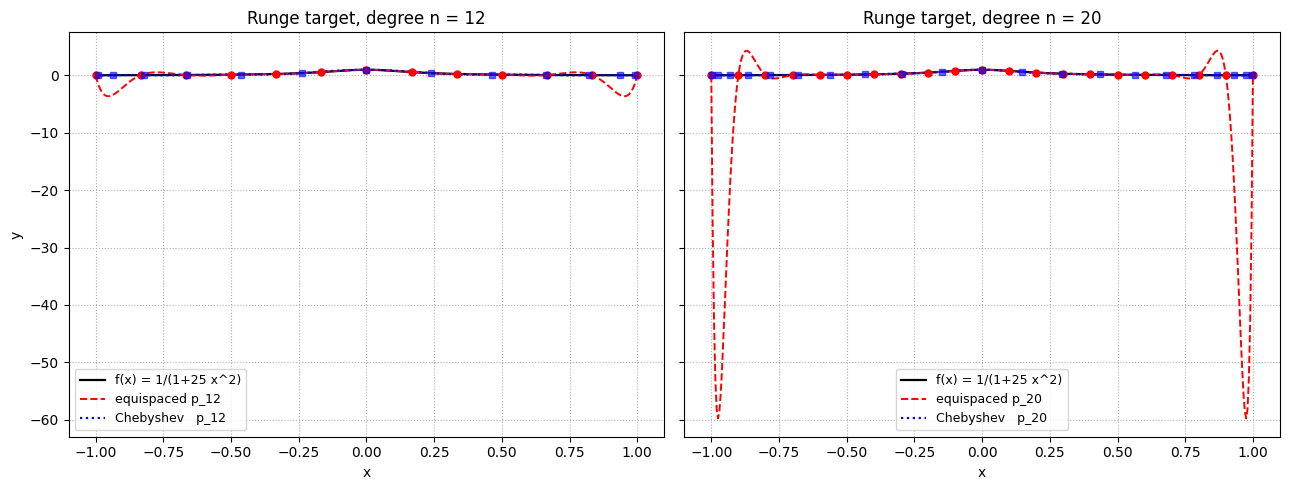

In [2]:
# ----- Plot 1: function + two interpolants at n = 12 and n = 20 -----
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0), sharey=True)
for ax, n in zip(axes, [12, 20]):
    xs_e, ys_e, p_e = store_eq[n]
    xs_c, ys_c, p_c = store_ch[n]
    ax.plot(xdense, fdense, "k-", lw=1.6, label="f(x) = 1/(1+25 x^2)")
    ax.plot(xdense, p_e, "r--", lw=1.4, label=f"equispaced p_{n}")
    ax.plot(xdense, p_c, "b:",  lw=1.6, label=f"Chebyshev   p_{n}")
    ax.plot(xs_e, ys_e, "ro", ms=5)
    ax.plot(xs_c, ys_c, "bs", ms=5, alpha=0.6)
    ax.set_xlabel("x")
    ax.set_title(f"Runge target, degree n = {n}")
    ax.grid(True, ls=":")
    ax.legend(fontsize=9)
axes[0].set_ylabel("y")
plt.tight_layout()
plt.show()


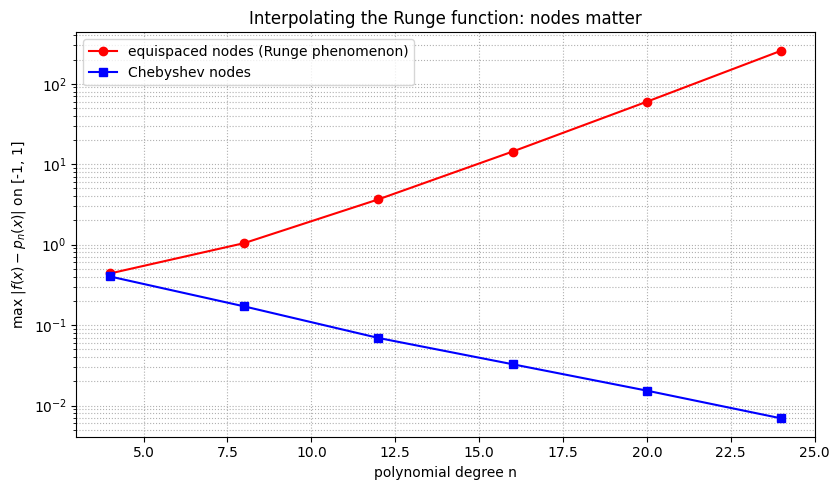

In [3]:
# ----- Plot 2: max error vs degree -----
fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.semilogy(ns, err_eq, "ro-", label="equispaced nodes (Runge phenomenon)")
ax.semilogy(ns, err_ch, "bs-", label="Chebyshev nodes")
ax.set_xlabel("polynomial degree n")
ax.set_ylabel(r"max $|f(x) - p_n(x)|$ on [-1, 1]")
ax.set_title("Interpolating the Runge function: nodes matter")
ax.grid(True, which="both", ls=":")
ax.legend()
plt.tight_layout()
plt.show()


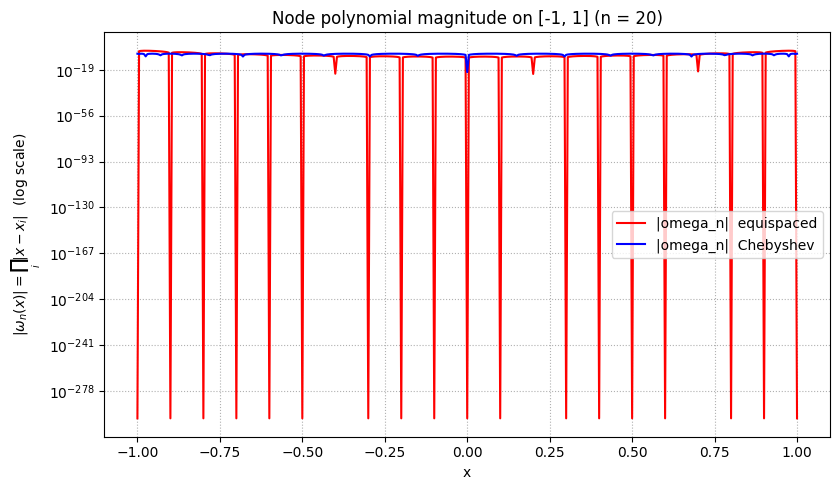

sup |omega_n|, equispaced n=20:  2.336e-04
sup |omega_n|, Chebyshev  n=20:  9.537e-07
Chebyshev  theoretical sup    :  2^(-n)  = 9.537e-07


In [4]:
# ----- Plot 3: node polynomial omega_n(x) for n = 20 -----
n_w = 20
xs_e = equispaced(n_w)
xs_c = np.sort(chebyshev(n_w))

def omega(xs, x):
    out = np.ones_like(x)
    for xi in xs:
        out *= (x - xi)
    return out

w_e = omega(xs_e, xdense)
w_c = omega(xs_c, xdense)

fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.semilogy(xdense, np.abs(w_e) + 1e-300, "r-", label="|omega_n|  equispaced")
ax.semilogy(xdense, np.abs(w_c) + 1e-300, "b-", label="|omega_n|  Chebyshev")
ax.set_xlabel("x")
ax.set_ylabel(r"$|\omega_n(x)| = \prod_i |x - x_i|$  (log scale)")
ax.set_title(f"Node polynomial magnitude on [-1, 1] (n = {n_w})")
ax.grid(True, which="both", ls=":")
ax.legend()
plt.tight_layout()
plt.show()

# print sup norms
print(f"sup |omega_n|, equispaced n={n_w}:  {np.max(np.abs(w_e)):.3e}")
print(f"sup |omega_n|, Chebyshev  n={n_w}:  {np.max(np.abs(w_c)):.3e}")
print(f"Chebyshev  theoretical sup    :  2^(-n)  = {2.0**(-n_w):.3e}")


## 4. 결과 해석

1. **등간격은 *발산*, Chebyshev 는 *수렴*.** 차수 $n$ 을 4 → 24 로 키우면
   등간격 보간의 max error 가 *오히려 커진다* (Runge 현상).
   반대로 Chebyshev 노드에서는 같은 함수에서 max error 가 *지수적* 으로 줄어
   $n = 24$ 에서 이미 $\sim 10^{-3}$ 수준.

2. **$\omega_n(x)$ 가 결정적.** 노드 다항식의 sup-norm 이
   - 등간격: $\|\omega_n\|_\infty$ 이 *지역적으로* 끝단에서 폭발 — 그 결과
     보간 오차는 $f^{(n+1)}/(n+1)!$ 의 부족분을 *덮어 쓴다*.
   - Chebyshev: $\|\omega_n\|_\infty = 2^{-n}$ — *어떤* 노드 선택보다 작고,
     equioscillation 으로 *평평하다*.

   세 번째 그래프에서 둘의 *값 자체* 차이를 직접 확인할 수 있다.

3. **함수의 *복소* 정보가 보간을 결정한다.** Runge 함수가 실수 위에서
   부드러워 보여도, 복소평면의 극 $x = \pm i/5$ 가 *수렴 반경* 을 막는다.
   Chebyshev 노드는 *Bernstein 타원* 영역에서 수렴을 보장하므로 이 극을
   피해 갈 수 있다 — 이것이 *minimax* 성질의 본질.

4. **실무적 함의.** 다항식 보간을 사용하려면 **거의 항상 Chebyshev (또는 그 변형)
   노드** 를 써야 한다.  등간격 데이터가 강제될 때는 다항식 대신
   *조각별 다항식* (spline, Day 16 +) 이나 *유리함수 보간* 이 답.

> **결론**: 차수를 키운다고 보간이 좋아지지 않는다 — *노드 분포* 가 본질이다.
> Chebyshev 노드는 어떤 분포보다 $\|\omega_n\|_\infty$ 를 작게 만들어,
> Runge 함수처럼 까다로운 대상에서도 *지수* 수렴을 가능케 한다.

### 다음 단원 예고 (Day 15)
**§4.2 — Errors in Polynomial Interpolation** 으로 넘어가 위에서 본
*노드 다항식* 의 거동을 정량화한다.  $\|\omega_n\|_\infty$ 의 *근사* 와
*Lebesgue 상수* $\Lambda_n$ 의 의미, Chebyshev 가 *minimax* 인 정확한 의미를
정리/증명/시각화로 확인한다.
